In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import seaborn as sns

In [26]:
df = pd.read_csv("health_fitness_dataset.csv")

In [27]:
df.head()

,exercise_minutes,steps,food_calories,sleep_hours,water_intake_liters,weight
0,42.9,7469.0,2172.0,8.3,3.39,81.12
1,75.9,--,1898.0,6.2,3.66,78.62
2,49.2,unknown,2063.0,9.2,2.92,77.21
3,64.9,4229.0,2443.0,5.6,2.29,89.47
4,42.7,9535.0,1815.0,6.6,1.48,80.41


In [28]:
df.shape

(500, 6)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   exercise_minutes     485 non-null    float64
 1   steps                499 non-null    object 
 2   food_calories        498 non-null    object 
 3   sleep_hours          498 non-null    object 
 4   water_intake_liters  500 non-null    float64
 5   weight               490 non-null    float64
dtypes: float64(3), object(3)
memory usage: 23.6+ KB


In [30]:
df.describe()

,exercise_minutes,water_intake_liters,weight
count,485.000000,500.000000,490.000000
mean,45.091959,2.463280,82.844816
std,16.309447,0.742059,16.018396
min,-25.000000,-2.000000,64.190000
25%,36.200000,2.080000,78.190000
50%,45.500000,2.480000,81.750000
75%,56.100000,2.930000,84.800000
max,88.100000,4.560000,300.000000


In [31]:
df.isnull().sum()

exercise_minutes       15
steps                   1
food_calories           2
sleep_hours             2
water_intake_liters     0
weight                 10
dtype: int64

In [32]:
df["exercise_minutes"] = df["exercise_minutes"].replace("unknown", np.nan)
df["steps"] = df["steps"].replace("unknown", np.nan)
df["food_calories"] = df["food_calories"].replace("unknown", np.nan)
df["sleep_hours"] = df["sleep_hours"].replace("unknown", np.nan)
df["water_intake_liters"] = df["water_intake_liters"].replace("unknown", np.nan)
df["weight"] = df["weight"].replace("unknown", np.nan)
# handle all unknown values with nan values

In [33]:
cols = [
    'exercise_minutes',
    'steps',
    'food_calories',
    'sleep_hours',
    'water_intake_liters',
    'weight'
]

for col in cols:
    # Convert invalid values to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Fill NaN values with column mean
    df[col] = df[col].fillna(df[col].mean())

In [34]:
df.head(50)

,exercise_minutes,steps,food_calories,sleep_hours,water_intake_liters,weight
0,42.900000,7469.00000,2172.000000,8.3,3.39,81.12
1,75.900000,8127.92915,1898.000000,6.2,3.66,78.62
2,49.200000,8127.92915,2063.000000,9.2,2.92,77.21
3,64.900000,4229.00000,2443.000000,5.6,2.29,89.47
4,42.700000,9535.00000,1815.000000,6.6,1.48,80.41
5,44.000000,5857.00000,1677.000000,4.7,3.01,81.46
6,56.300000,6770.00000,2875.000000,4.0,2.62,94.16
7,57.400000,8171.00000,1544.000000,7.1,1.83,75.67
8,43.300000,8696.00000,2579.000000,8.9,2.13,86.39
9,45.091959,11479.00000,964.000000,5.1,1.10,72.81


In [35]:
df.duplicated().sum() # it searches for any duplicate values

np.int64(0)

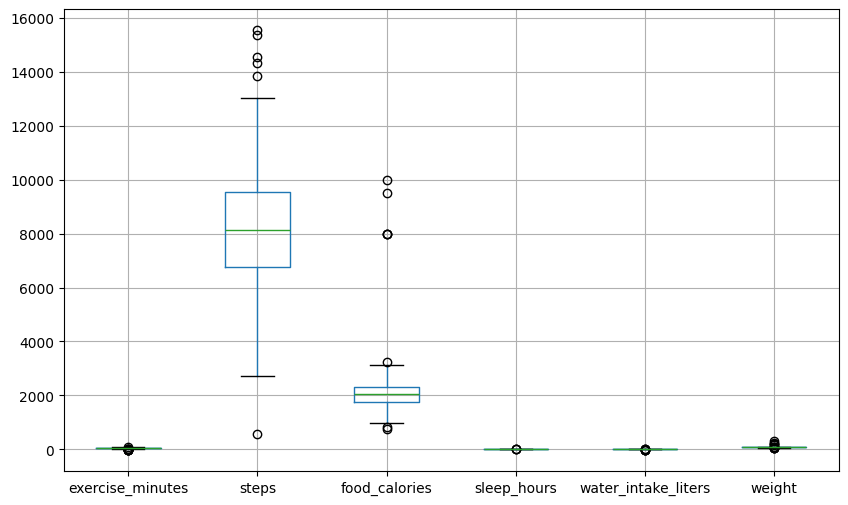

In [36]:
df.boxplot(figsize=(10,6))
plt.show() # we use graph to see if there are any outliers and if yes then we will remove it

In [37]:
cols = [
    'exercise_minutes',
    'steps',
    'food_calories',
    'sleep_hours',
    'water_intake_liters',
    'weight'
]

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    # removing outliers using IQR method

In [38]:
print(df.corr()) # with the help of correlation we can decide which columns are tightly or ossely affecting which columns so while making models we can use those columns as feature to predict the target.

                     exercise_minutes     steps  food_calories  sleep_hours  \
exercise_minutes             1.000000  0.037231       0.007231    -0.055663   
steps                        0.037231  1.000000       0.029791    -0.031773   
food_calories                0.007231  0.029791       1.000000     0.067207   
sleep_hours                 -0.055663 -0.031773       0.067207     1.000000   
water_intake_liters          0.009474 -0.018348       0.090132     0.019360   
weight                      -0.158297 -0.336284       0.751514    -0.124744   

                     water_intake_liters    weight  
exercise_minutes                0.009474 -0.158297  
steps                          -0.018348 -0.336284  
food_calories                   0.090132  0.751514  
sleep_hours                     0.019360 -0.124744  
water_intake_liters             1.000000 -0.081747  
weight                         -0.081747  1.000000  


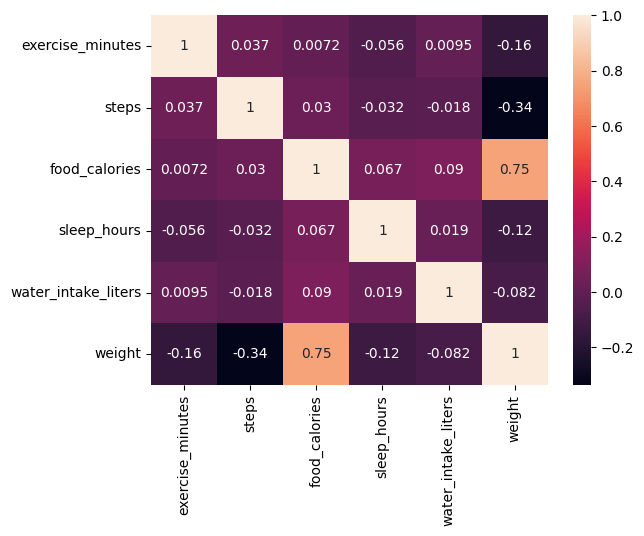

In [39]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [40]:
# now model making starts 

X = df.drop("weight", axis=1)
Y = df["weight"]
X.head()
# Y.head()

,exercise_minutes,steps,food_calories,sleep_hours,water_intake_liters
0,42.9,7469.00000,2172.0,8.3,3.39
1,75.9,8127.92915,1898.0,6.2,3.66
2,49.2,8127.92915,2063.0,9.2,2.92
3,64.9,4229.00000,2443.0,5.6,2.29
4,42.7,9535.00000,1815.0,6.6,1.48


In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.6,
    random_state=42
)
# Variable	    Meaning
# X_train	    Training input data
# y_train	    Training correct answers
# X_test	    Testing input data
# y_test	    Testing correct answers

model=LinearRegression() # even if there are multiple inputs then also we write only linear regression and not mulitple linear regression as it will handle both type of inputs automatically.

In [42]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
print(model.coef_[0])
print(model.intercept_)

-0.06876732517031807
80.60997041728282


In [44]:
prediction = model.predict(
    [[45, 8000, 2200, 7, 3]]
)

print(prediction)

[82.52505502]


C:\Users\Akshar Bhavsar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [45]:
prediction = model.predict(X_test)
print(r2_score(prediction,Y_test))

0.7718327723543079


In [46]:
import pickle
pickle.dump(model,open("health_fitness.pkl","wb"))